In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
tab_arr = []

model_dict = {
    "deitsmall": "facebook/deit-small-patch16-224",
    "dinobase": "facebook/dinov2-base",
    "vitlarge": "google/vit-large-patch16-224"
}

model_reverse_dict = {
    "facebook/deit-small-patch16-224": "deitsmall",
    "facebook/dinov2-base": "dinobase",
    "google/vit-large-patch16-224": "vitlarge"
}

model_layers_dict = {
    "deitsmall": 12,
    "dinobase": 12,
    "vitlarge": 24
    }
model_heads_dict = {
    "deitsmall": 6,
    "dinobase": 12,
    "vitlarge": 16
    }
dataset_dict = {
    "mnist": "mnist",
    "cifar100": "cifar100",
    "imagenet1k": "imagenet-1k"
}

for dataset in ["mnist", "cifar100", "imagenet1k"]:
    for model in ["deitsmall", "dinobase", "vitlarge"]:
        num_layers = model_layers_dict[model]
        num_heads = model_heads_dict[model]
        tab = pd.read_csv(f"../outputs/{model}_{dataset}.csv")
        for i in range(0, num_layers):
            tab[f"layer_{i}_keep"] = tab[f"layer_{i}_keep"].apply(lambda x: [int(n) for n in str(x).split(" ")])
        tab["total_heads_kept"] = tab[[f"layer_{i}_keep" for i in range(0, num_layers)]].apply(lambda x: sum([len(l) for l in x]), axis=1) 
        tab["head_dict"] = tab.apply(lambda row: {int(f"{i}"): row[f"layer_{i}_keep"] for i in range(0, num_layers) if len(row[f"layer_{i}_keep"]) < num_heads}, axis=1)
        tab["dataset"] = dataset_dict[dataset]
        tab["encoder"] = model_dict[model]
        tab = tab[["dataset", "encoder", "total_heads_kept", "head_dict", "threshold"]]
        new_row = {"dataset" : dataset_dict[dataset], "encoder": model_dict[model], "total_heads_kept": num_heads*num_layers, "head_dict": {}, "threshold": 1}
        new_row_df = pd.DataFrame([new_row])
        tab = pd.concat([new_row_df, tab], ignore_index=True)
        tab_arr.append(tab)



experiments = pd.concat(tab_arr, ignore_index=True)
experiments["skip"] = "[]"
experiments["mlp_skip"] = "[]"
experiments["attn_skip"] = "[]"
experiments["skip_translator"] = "identity"
experiments["mlp_mode"] = "identity"
experiments["attn_mode"] = "identity"
experiments_data = experiments[["dataset", "encoder", "total_heads_kept", "head_dict", "threshold"]]

experiments["head_dict"] = experiments["head_dict"].apply(str)
experiments = experiments[["dataset", "encoder", "skip", "mlp_skip", "attn_skip", "head_dict", "skip_translator", "mlp_mode", "attn_mode"]]
experiments = experiments.drop_duplicates()
experiments.to_csv("../outputs/experiments.csv", index=False)
experiments_data.to_csv("../outputs/experiments_metadata.csv", index=False)

In [30]:
experiments_data

,dataset,encoder,total_heads_kept,head_dict,threshold
0,mnist,facebook/deit-small-patch16-224,72,{},1.00
1,mnist,facebook/deit-small-patch16-224,12,"{0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0...",0.05
2,mnist,facebook/deit-small-patch16-224,12,"{0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0...",0.10
3,mnist,facebook/deit-small-patch16-224,13,"{0: [0], 1: [0, 1], 2: [0], 3: [0], 4: [0], 5:...",0.15
4,mnist,facebook/deit-small-patch16-224,14,"{0: [0], 1: [0, 1, 2], 2: [0], 3: [0], 4: [0],...",0.20
...,...,...,...,...,...
175,imagenet-1k,google/vit-large-patch16-224,199,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 9, 15], 1: [0, 1,...",0.75
176,imagenet-1k,google/vit-large-patch16-224,280,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...",0.80
177,imagenet-1k,google/vit-large-patch16-224,336,"{3: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13...",0.85
178,imagenet-1k,google/vit-large-patch16-224,382,"{22: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, ...",0.90


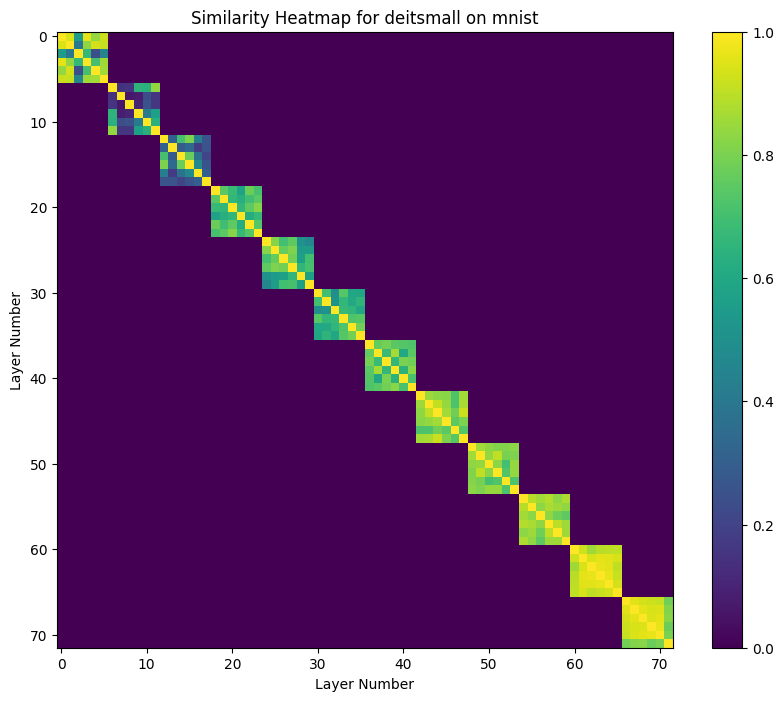

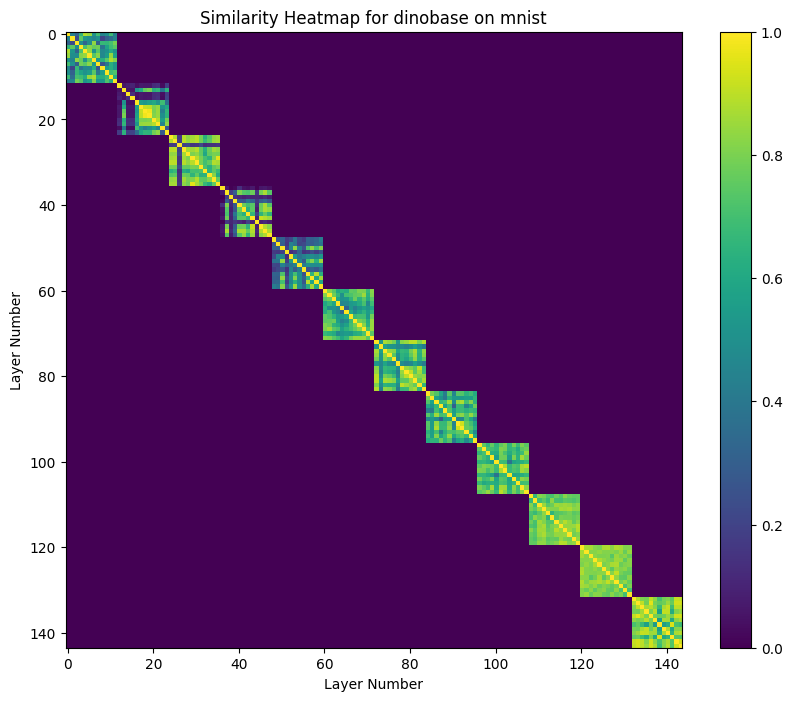

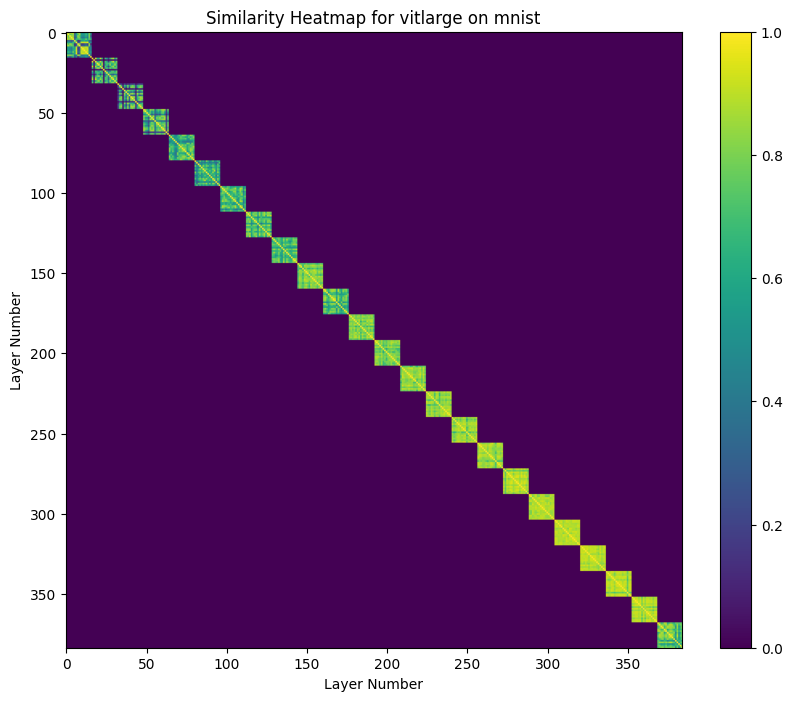

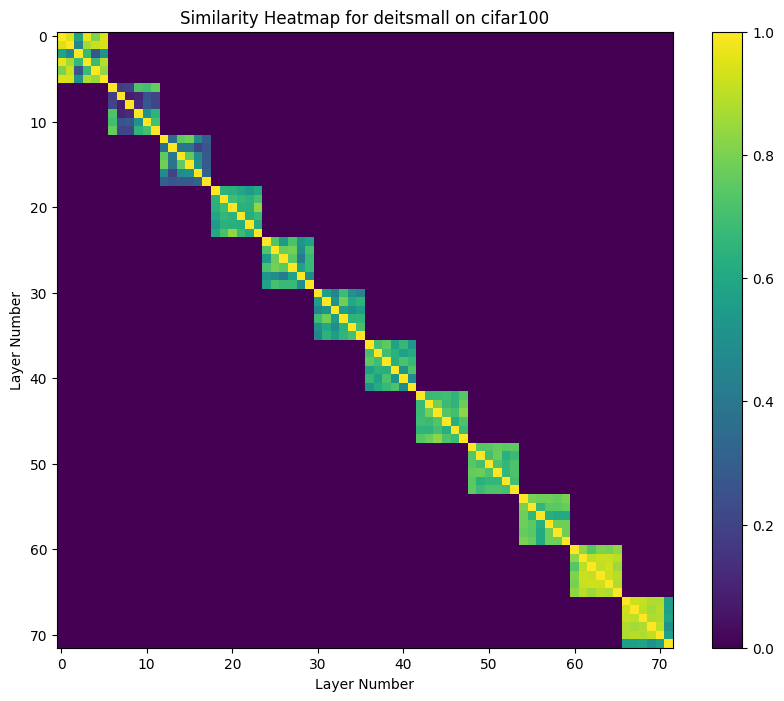

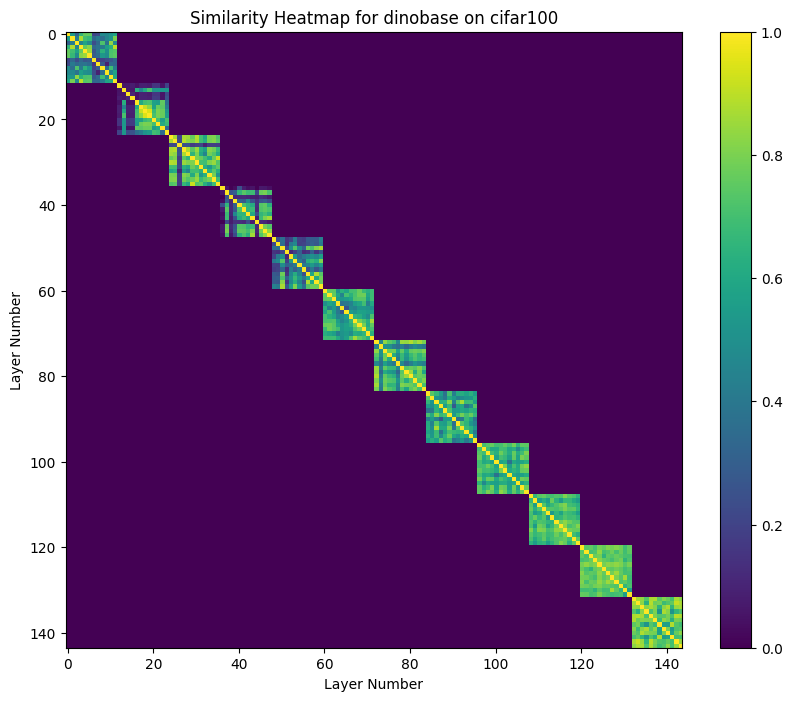

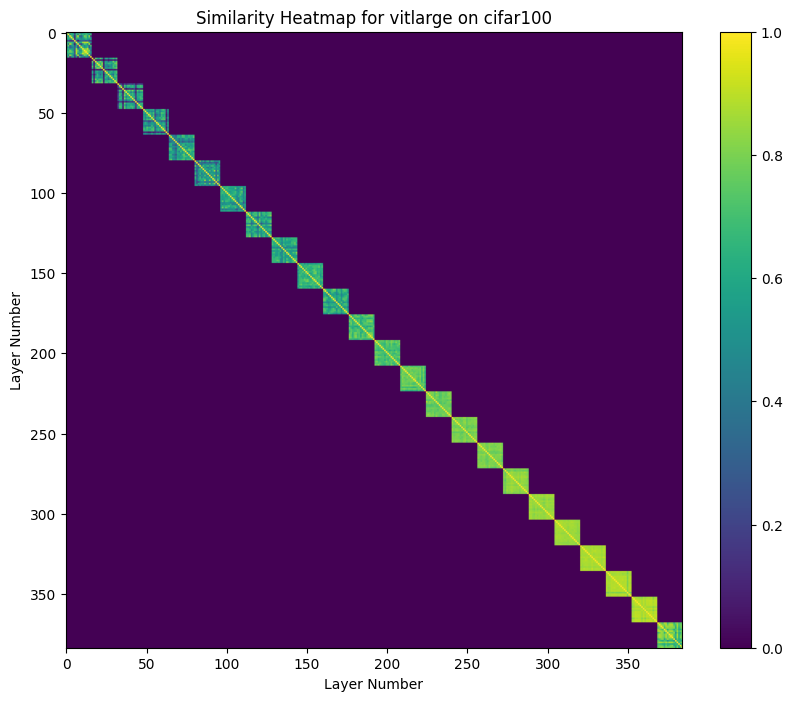

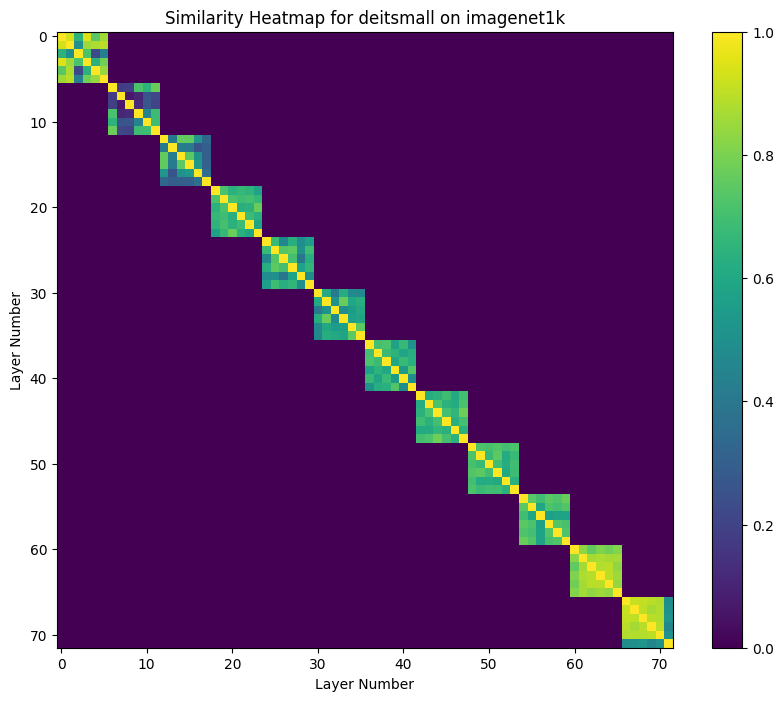

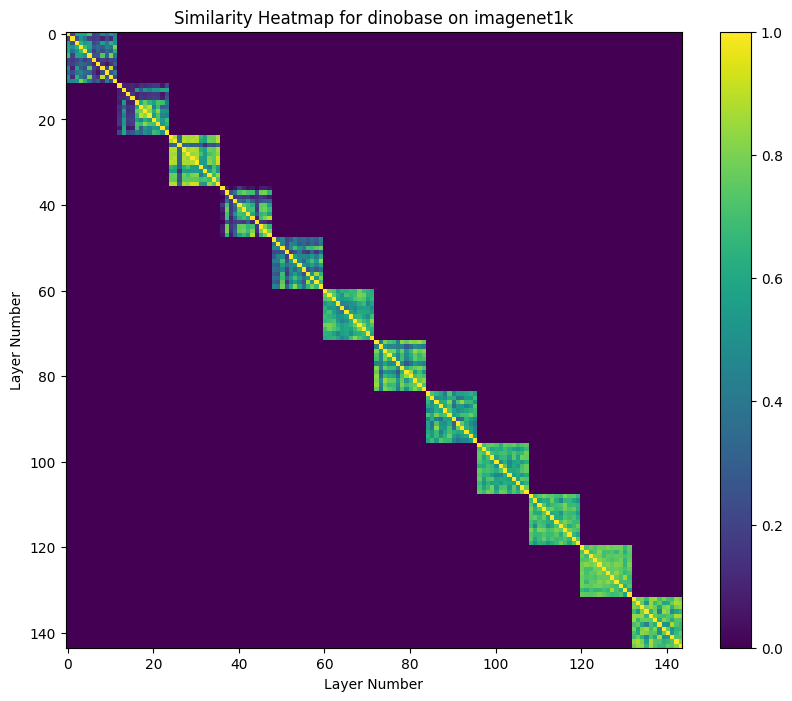

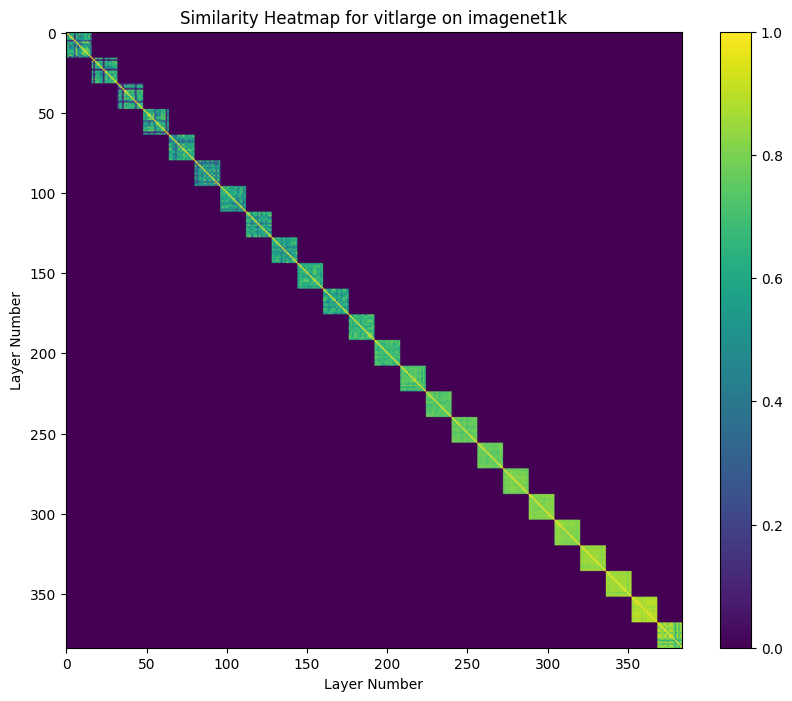

In [31]:
for dataset in ["mnist", "cifar100", "imagenet1k"]:
    for model in ["deitsmall", "dinobase", "vitlarge"]:
        similarity = np.load(f"../outputs/{model}_{dataset}_similarity.npy")
        num_layers, num_heads, _ = similarity.shape
        similarity_reshaped = np.zeros((num_layers * num_heads, num_layers * num_heads))
        for i in range(num_layers):
            similarity_reshaped[i*num_heads:(i+1)*num_heads, i*num_heads:(i+1)*num_heads] = similarity[i]

        plt.figure(figsize=(10, 8))
        plt.imshow(similarity_reshaped, cmap='viridis')
        plt.colorbar()
        plt.xlabel('Layer Number')
        plt.ylabel('Layer Number')
        plt.title(f'Similarity Heatmap for {model} on {dataset}')

In [32]:
tab = pd.read_csv("../outputs/results_full_heads.csv")
meta = pd.read_csv("../outputs/experiments_metadata.csv")

In [33]:
# cast head_dict from string to dict
tab["head_dict"] = tab["head_dict"].apply(eval)
tab["total_heads_kept"] = tab.apply(lambda row: model_heads_dict[model_reverse_dict[row['model']]] * model_layers_dict[model_reverse_dict[row['model']]] - sum([model_heads_dict[model_reverse_dict[row['model']]] - len(x) for x in dict(row['head_dict']).values()]) , axis=1)
tab["head_dict"] = tab["head_dict"].apply(lambda x: str(x))

In [34]:
tab["skip_config"] = tab.apply(lambda row: f"Encoder: {row['model']}, Dataset: {row['dataset']}, Block: {row['approx_layer']}, Block Mode: {row['translator']}, MLP: {row['mlp_linearize']}, MLP Mode: {row['mlp_mode']}, Attn: {row['attn_linearize']} Heads: {row['head_dict']}", axis=1)
accuracies = tab[["model", "dataset", "head_dict", "total_heads_kept", "accuracy"]].groupby(["model", "dataset", "head_dict", "total_heads_kept"]).agg({"accuracy": ["mean", "std"]}).reset_index()
accuracies.columns = ["model", "dataset", "head_dict", "total_heads_kept", "accuracy_mean", "accuracy_std"]


In [35]:
meta.rename(columns={"encoder": "model"}, inplace=True)

In [36]:
accuracies.to_csv("../outputs/accuracies.csv", index=False)

In [37]:
meta.head(19)

,dataset,model,total_heads_kept,head_dict,threshold
0,mnist,facebook/deit-small-patch16-224,72,{},1.00
1,mnist,facebook/deit-small-patch16-224,12,"{0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0...",0.05
2,mnist,facebook/deit-small-patch16-224,12,"{0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0...",0.10
3,mnist,facebook/deit-small-patch16-224,13,"{0: [0], 1: [0, 1], 2: [0], 3: [0], 4: [0], 5:...",0.15
4,mnist,facebook/deit-small-patch16-224,14,"{0: [0], 1: [0, 1, 2], 2: [0], 3: [0], 4: [0],...",0.20
5,mnist,facebook/deit-small-patch16-224,14,"{0: [0], 1: [0, 1, 2], 2: [0], 3: [0], 4: [0],...",0.25
6,mnist,facebook/deit-small-patch16-224,15,"{0: [0], 1: [0, 1, 2], 2: [0, 5], 3: [0], 4: [...",0.30
7,mnist,facebook/deit-small-patch16-224,16,"{0: [0], 1: [0, 1, 2], 2: [0, 1, 5], 3: [0], 4...",0.35
8,mnist,facebook/deit-small-patch16-224,16,"{0: [0], 1: [0, 1, 2], 2: [0, 1, 5], 3: [0], 4...",0.40
9,mnist,facebook/deit-small-patch16-224,17,"{0: [0], 1: [0, 1, 2], 2: [0, 1, 4, 5], 3: [0]...",0.45


In [38]:
encoder_data = pd.merge(accuracies, meta, on=["dataset", "model", "head_dict","total_heads_kept"], how="right").sort_values(by=["dataset", "model", "threshold"])
attention_head_size_dict = {
    "deitsmall": 0.098,
    "dinobase": 0.196,
    "vitlarge": 0.262
    }
model_size_dict = {
    "deitsmall": 22.1,
    "dinobase": 86.0,
    "vitlarge": 307.0
    }

encoder_data["attention_head_saving"] = encoder_data.apply(lambda x: attention_head_size_dict[model_reverse_dict[x["model"]]] * (model_layers_dict[model_reverse_dict[x["model"]]] * model_heads_dict[model_reverse_dict[x["model"]]] - x["total_heads_kept"]), axis=1)
encoder_data["model_size"] = encoder_data.apply(lambda x: model_size_dict[model_reverse_dict[x["model"]]] - x["attention_head_saving"], axis=1)

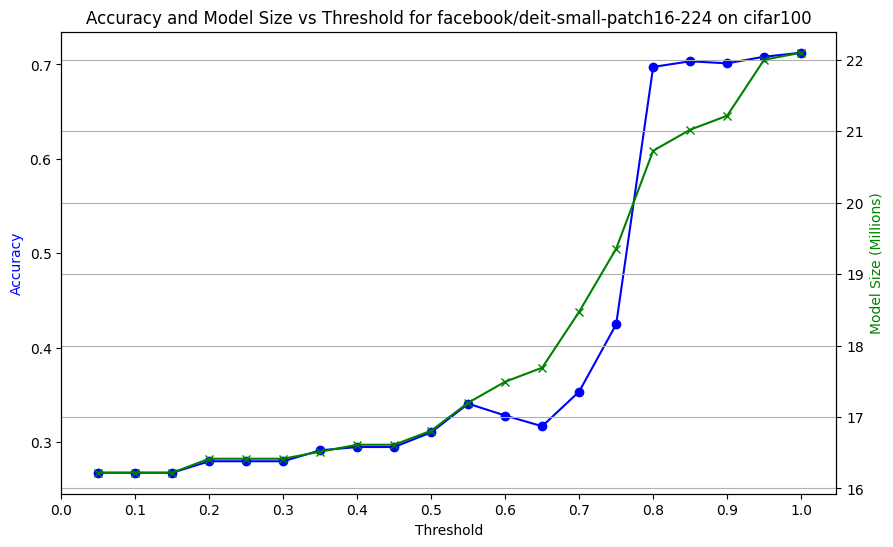

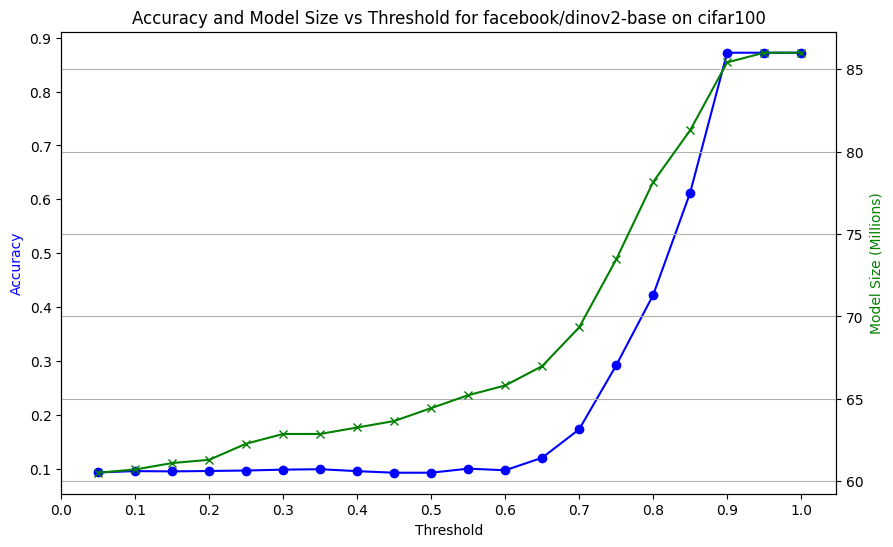

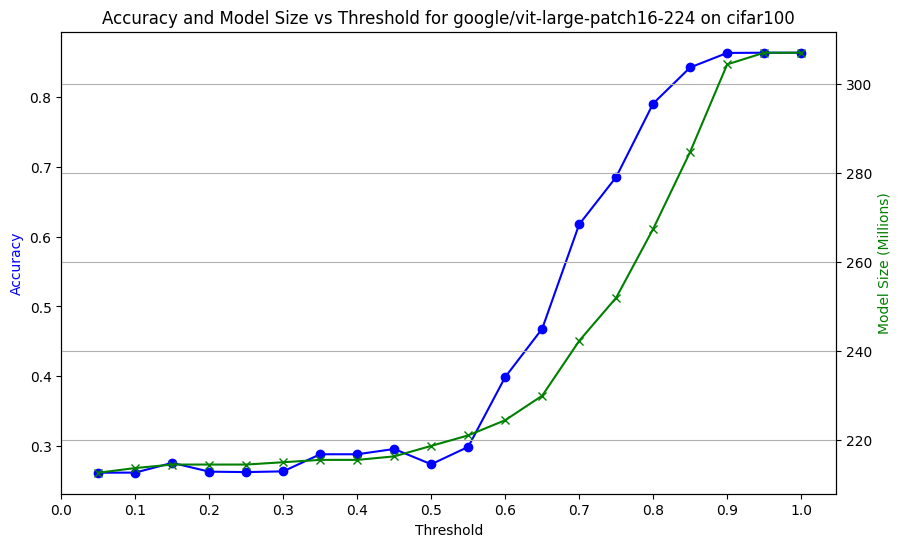

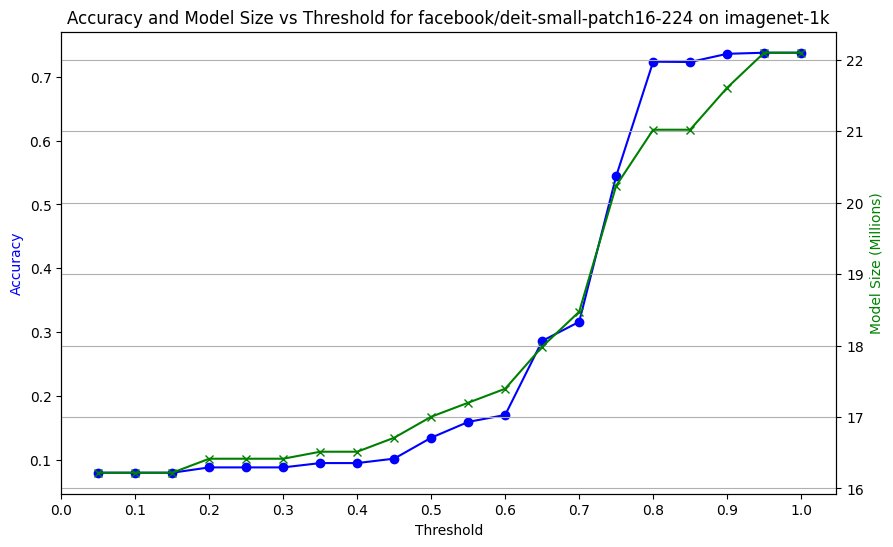

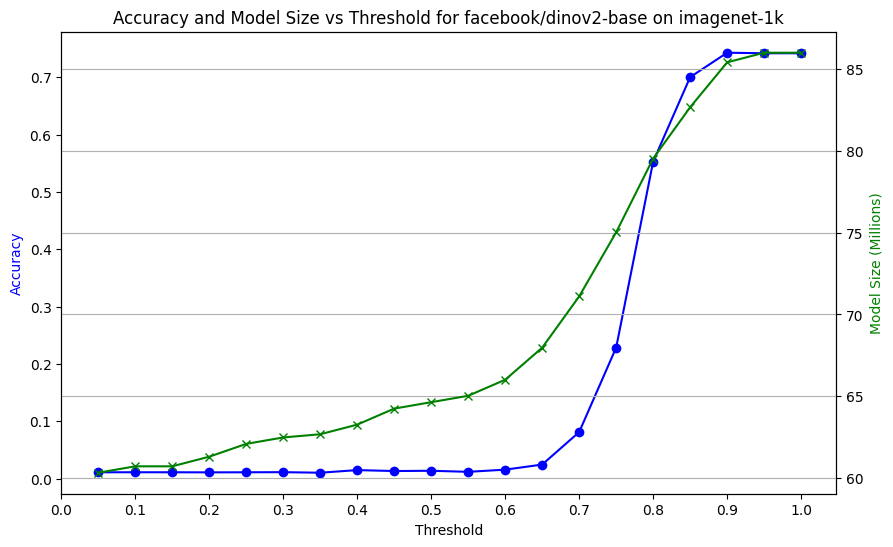

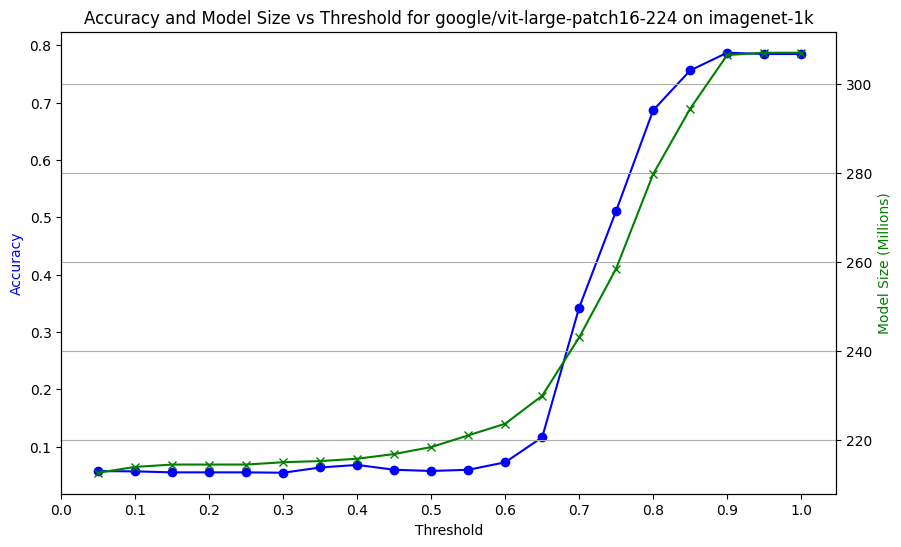

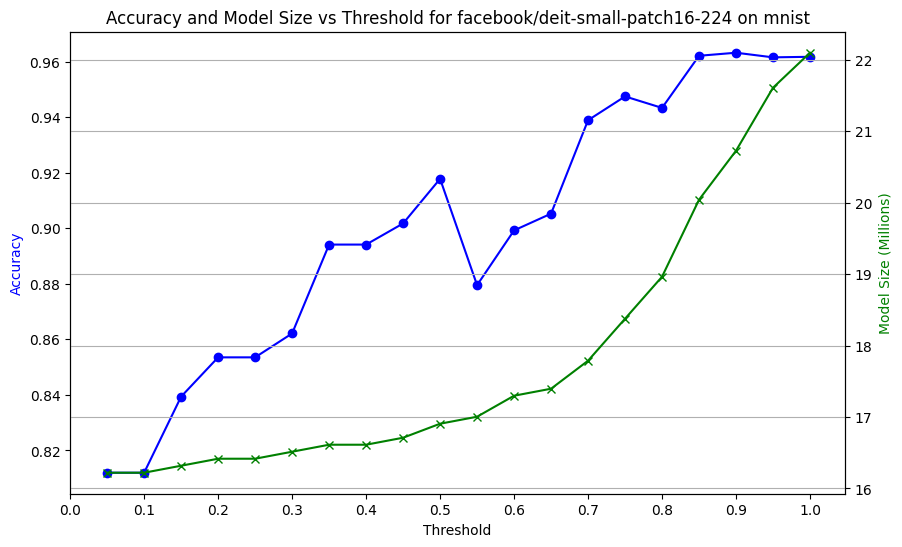

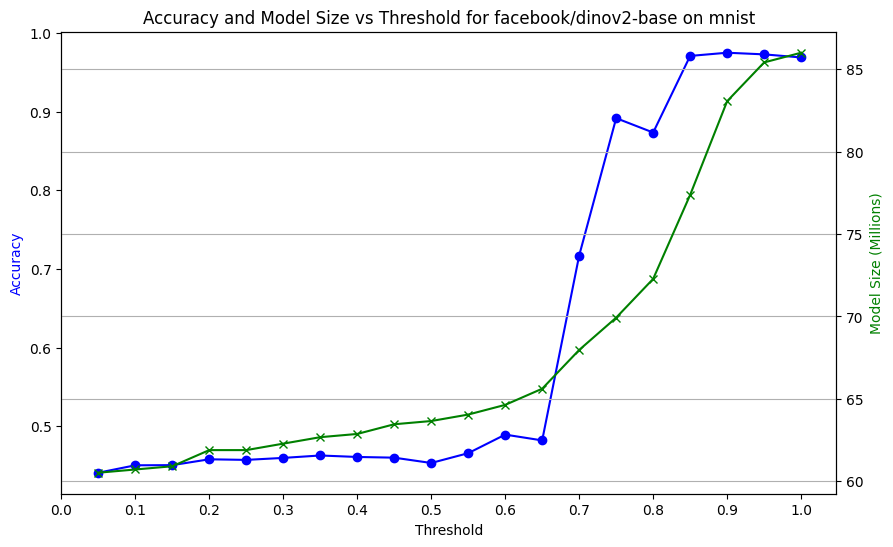

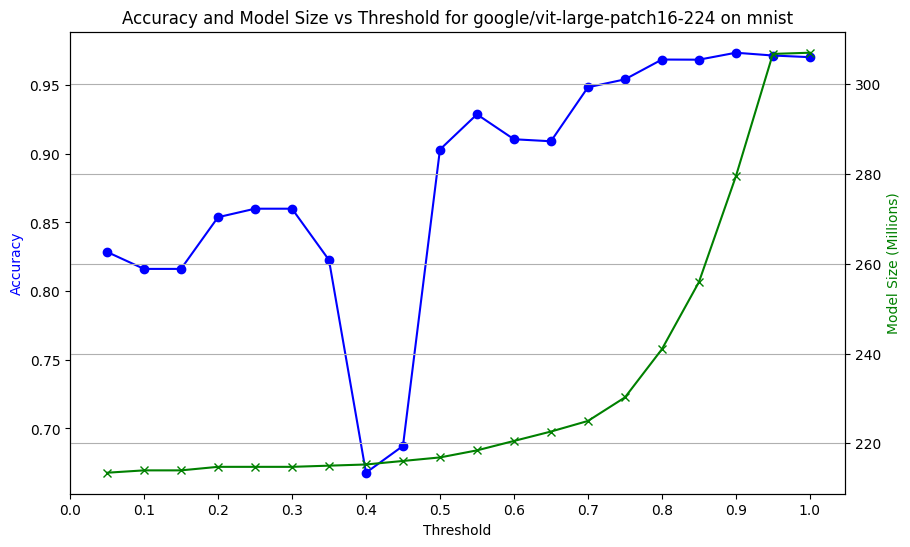

In [49]:
# do one plot per dataset and model combination
# make bar plot for parameters count and line plot for accuracy with error bars
for dataset in encoder_data['dataset'].unique():
    for model in encoder_data['model'].unique():
        subset = encoder_data[(encoder_data['dataset'] == dataset) & (encoder_data['model'] == model)]
        plt.figure(figsize=(10, 6))
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        ax1.plot(subset['threshold'], subset['accuracy_mean'], marker='o', label='Accuracy', color='b')
        #ax2.bar(subset['threshold'], subset['parameters_count'], label='Parameters Count', color='g', alpha=0.5, width=0.04)
        ax2.plot(subset['threshold'], subset['model_size'], marker='x', label='Model Size', color='g')
        ax1.set_xlabel('Threshold')
        ax1.set_ylabel('Accuracy', color='b')
        ax2.set_ylabel('Model Size (Millions)', color='g')   
        ax2.set_xticks(0.1 * np.arange(0, 11))
        ax1.set_title(f'Accuracy and Model Size vs Threshold for {model} on {dataset}')
        plt.grid()
        plt.savefig(f"../outputs/plots/{model_reverse_dict[model]}_{dataset}_accuracy_model_size.png")


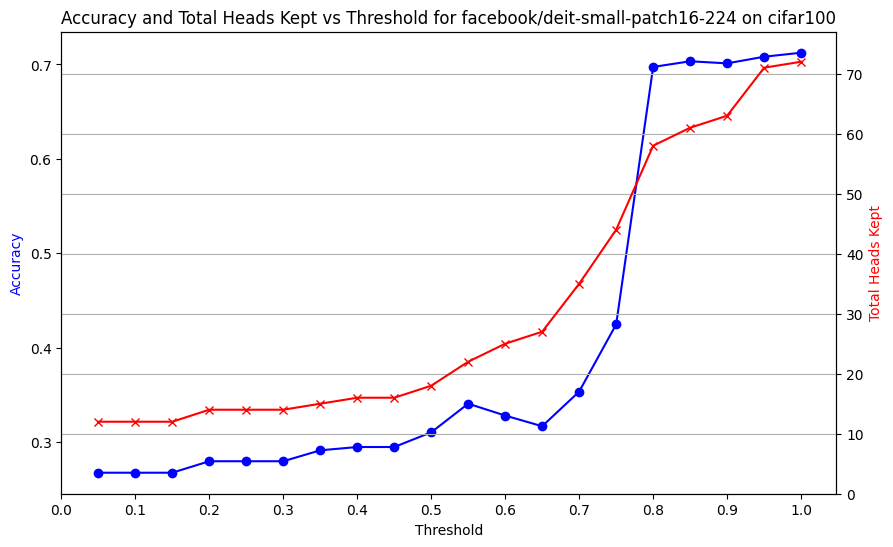

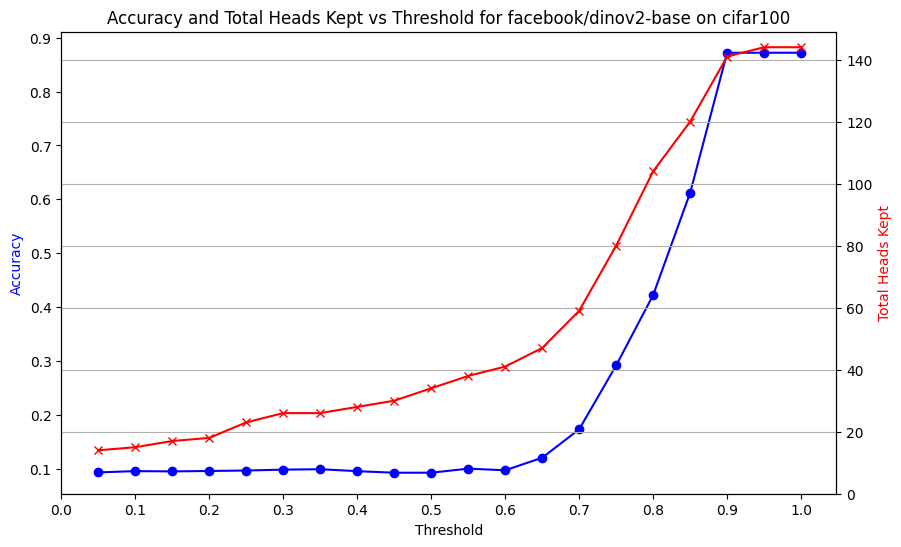

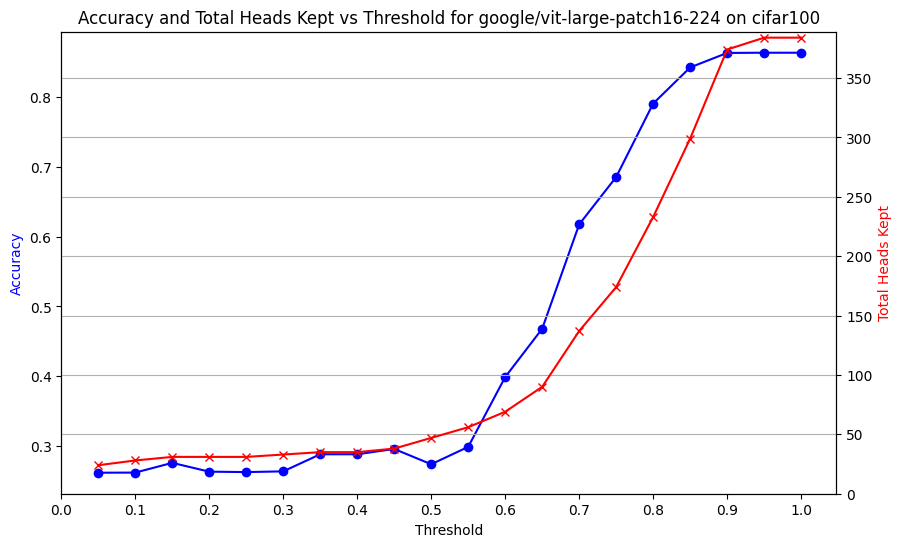

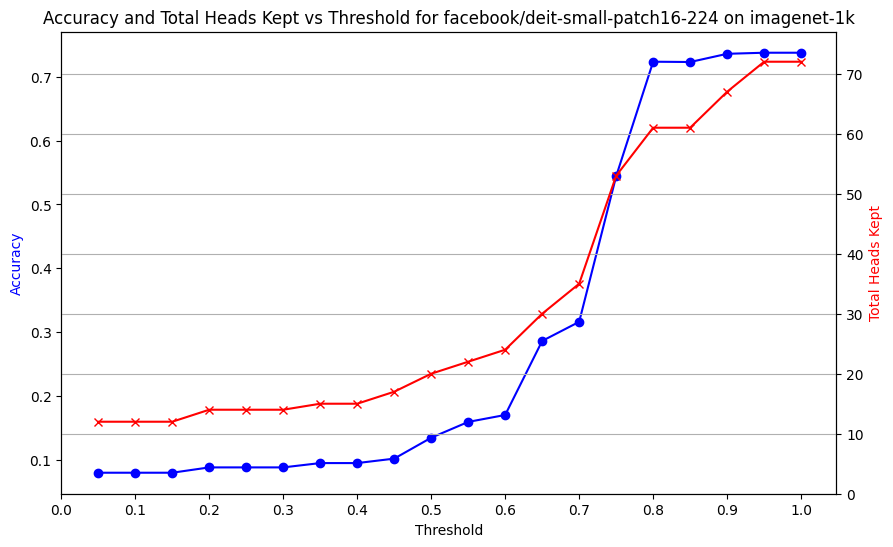

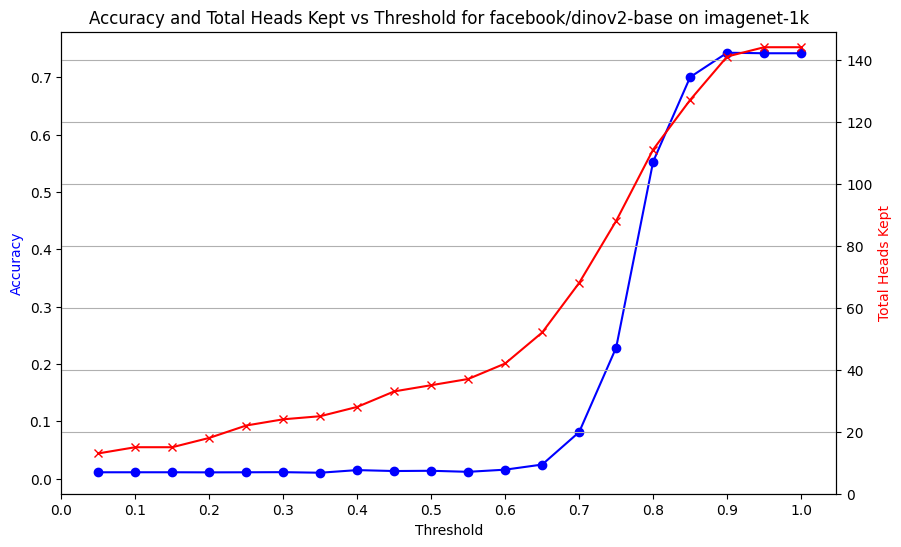

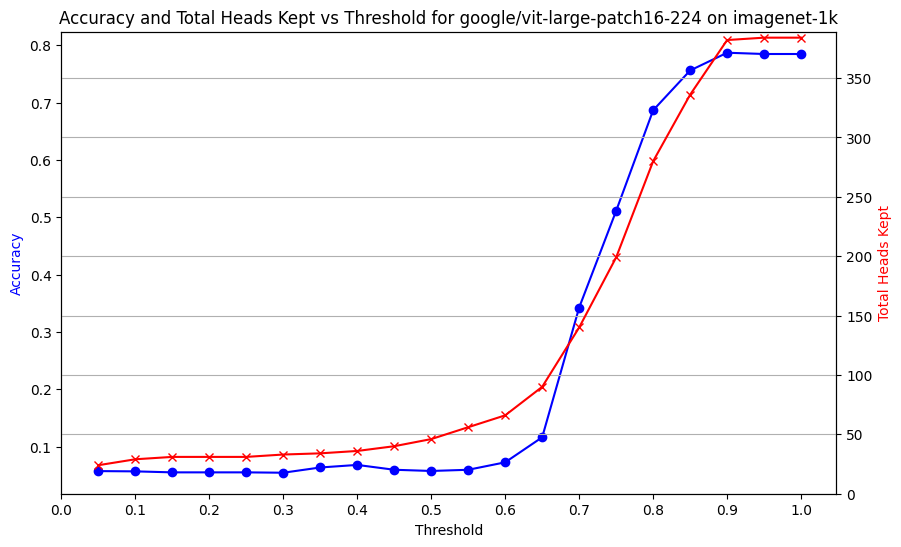

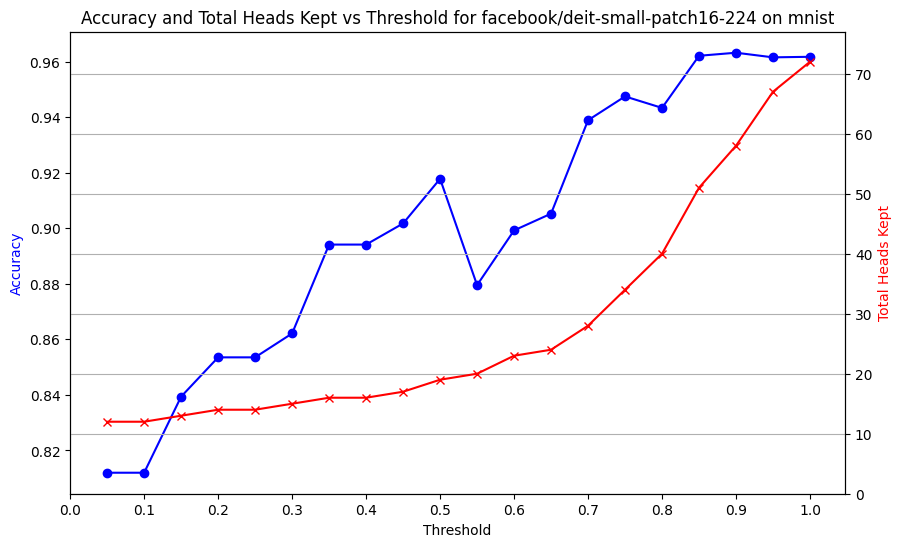

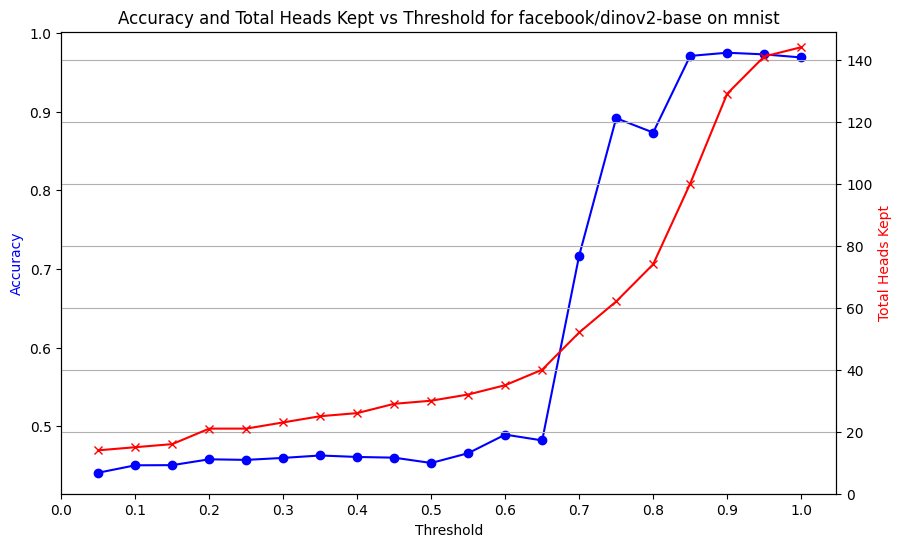

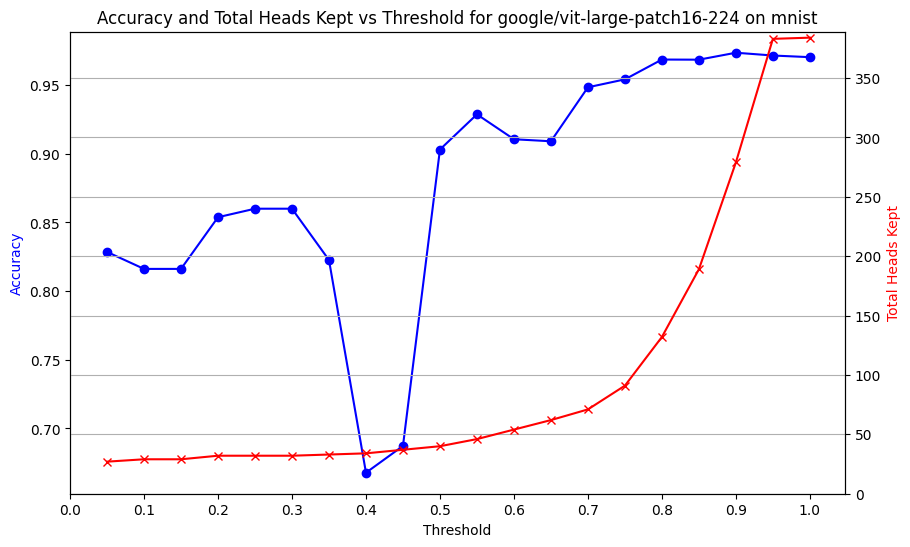

In [48]:
for dataset in encoder_data['dataset'].unique():
    for model in encoder_data['model'].unique():
        subset = encoder_data[(encoder_data['dataset'] == dataset) & (encoder_data['model'] == model)]
        plt.figure(figsize=(10, 6))
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        ax1.plot(subset['threshold'], subset['accuracy_mean'], marker='o', label='Accuracy', color='b')
        #ax2.bar(subset['threshold'], subset['parameters_count'], label='Parameters Count', color='g', alpha=0.5, width=0.04)
        ax2.plot(subset['threshold'], subset['total_heads_kept'], marker='x', label='Total Heads Kept', color='r')
        ax1.set_xlabel('Threshold')
        ax1.set_ylabel('Accuracy', color='b')
        ax2.set_ylabel('Total Heads Kept', color='r')   
        ax2.set_xticks(0.1 * np.arange(0, 11))
        ax2.set_ylim(0, model_layers_dict[model_reverse_dict[model]] * model_heads_dict[model_reverse_dict[model]] + 5)
        ax1.set_title(f'Accuracy and Total Heads Kept vs Threshold for {model} on {dataset}')
        plt.grid()
        plt.savefig(f"../outputs/plots/{model_reverse_dict[model]}_{dataset}_accuracy_total_heads_kept.png")

In [40]:
encoder_data.to_csv("../outputs/encoder_data.csv", index=False)